# DeBERTa-v3-Large + Optuna HPO

T4 x2, cosine LR, BCE + ranking loss, Optuna TPE + MedianPruner.

In [1]:
!pip install -q optuna

In [2]:
import contextlib, json, warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import optuna
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from transformers import (AutoConfig, AutoModelForSequenceClassification,
                          AutoTokenizer, get_cosine_schedule_with_warmup)
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, f1_score, brier_score_loss
from sklearn.model_selection import StratifiedShuffleSplit

try:
    from torch.amp import GradScaler, autocast
except ImportError:
    from torch.cuda.amp import GradScaler, autocast

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

DEV = "cuda" if torch.cuda.is_available() else "cpu"
N_GPUS = torch.cuda.device_count()
print(f"device: {DEV}  gpus: {N_GPUS}")
for i in range(N_GPUS):
    p = torch.cuda.get_device_properties(i)
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}  {p.total_memory/1e9:.1f} GB")

device: cuda  gpus: 2
  GPU 0: Tesla T4  15.6 GB
  GPU 1: Tesla T4  15.6 GB


In [ ]:
MDL_NM = "microsoft/deberta-v3-large"
MAX_LEN = 256
BATCH_SZ = 4 * max(N_GPUS, 1)
GRAD_ACCUM = max(1, 32 // BATCH_SZ)
EPOCHS = 4

TRN_FILE = "/kaggle/input/datasets/pan25-generative-ai-detection-task1-train/pan25-generative-ai-detection-task1-train/train.jsonl"
VAL_FILE = "/kaggle/input/datasets/pan25-generative-ai-detection-task1-train/pan25-generative-ai-detection-task1-train/val.jsonl"
CKPT_DIR = Path("/kaggle/working")
OUT_FILE = CKPT_DIR / "deberta_preds.jsonl"

OPTUNA_N_TRIALS = 15
OPTUNA_SUBSET_FRAC = 0.1
OPTUNA_EPOCHS = 1

In [4]:
def load_jsonl(path):
    with open(path) as f:
        return [json.loads(l) for l in f]

trn_recs = load_jsonl(TRN_FILE)
val_recs = load_jsonl(VAL_FILE)
print(f"train: {len(trn_recs)}  val: {len(val_recs)}")
ai = sum(r["label"] for r in trn_recs)
print(f"train label balance: human={len(trn_recs)-ai}  ai={ai}  ratio={ai/len(trn_recs):.3f}")

train: 23707  val: 3589
train label balance: human=9101  ai=14606  ratio=0.616


In [5]:
class TextDataset(Dataset):
    def __init__(self, recs, tok, max_len, smooth=0.0):
        self.recs = recs
        self.tok = tok
        self.max_len = max_len
        self.smooth = smooth

    def __len__(self):
        return len(self.recs)

    def __getitem__(self, i):
        r = self.recs[i]
        enc = self.tok(
            r["text"], max_length=self.max_len,
            truncation=True, padding="max_length", return_tensors="pt",
        )
        lbl = float(r["label"])
        if self.smooth > 0:
            lbl = lbl * (1 - self.smooth) + self.smooth / 2
        return {
            "input_ids": enc.input_ids.squeeze(),
            "attention_mask": enc.attention_mask.squeeze(),
            "label": torch.tensor(lbl, dtype=torch.float),
        }


def _focal(logits, labels, gamma=2.0):
    bce_per = F.binary_cross_entropy_with_logits(logits, labels, reduction="none")
    pt = torch.exp(-bce_per)
    return ((1 - pt) ** gamma * bce_per).mean()


def combined_loss(logits, labels, pos_weight, alpha_rank, rank_margin, loss_fn="bce_rank"):
    if "focal" in loss_fn:
        base = _focal(logits, labels)
    else:
        pw = torch.tensor(pos_weight, device=logits.device)
        base = F.binary_cross_entropy_with_logits(logits, labels, pos_weight=pw)

    if "rank" not in loss_fn:
        return base

    ai_idx = (labels >= 0.5).nonzero(as_tuple=True)[0]
    hmn_idx = (labels < 0.5).nonzero(as_tuple=True)[0]
    if len(ai_idx) == 0 or len(hmn_idx) == 0:
        return base
    n = min(len(ai_idx), len(hmn_idx))
    rank = F.relu(rank_margin - (logits[ai_idx[:n]] - logits[hmn_idx[:n]])).mean()
    return alpha_rank * rank + (1 - alpha_rank) * base

In [6]:
def pan_c_at_1(true_y, pred_y, thr=0.5):
    n = float(len(pred_y))
    nc, nu = 0.0, 0.0
    for gt, pred in zip(true_y, pred_y):
        if pred == thr:
            nu += 1
        elif (pred > thr) == (gt > thr):
            nc += 1.0
    return (1 / n) * (nc + (nu * nc / max(n - nu, 1)))


def pan_f05u(true_y, pred_y, thr=0.5):
    tp = fp = fn = nu = 0
    for t, p in zip(true_y, pred_y):
        if p == thr:
            nu += 1
        elif p > thr and t == 1:
            tp += 1
        elif p > thr and t != 1:
            fp += 1
        elif t == 1 and p <= thr:
            fn += 1
    denom = 1.25 * tp + 0.25 * (fn + nu) + fp
    return (1.25 * tp) / denom if denom else 0.0


def pan_eval(true_y, pred_y):
    scores = {
        "roc-auc": roc_auc_score(true_y, pred_y),
        "brier": 1 - brier_score_loss(true_y, pred_y),
        "c@1": pan_c_at_1(true_y, pred_y),
        "f1": f1_score(true_y, [1 if p >= 0.5 else 0 for p in pred_y]),
        "f0.5u": pan_f05u(true_y, pred_y),
    }
    scores["mean"] = float(np.mean(list(scores.values())))
    return {k: round(v, 4) for k, v in scores.items()}


def print_pan(sc, prefix=""):
    print(f"{prefix}roc-auc={sc['roc-auc']:.4f}  brier={sc['brier']:.4f}  "
          f"c@1={sc['c@1']:.4f}  f1={sc['f1']:.4f}  f0.5u={sc['f0.5u']:.4f}  mean={sc['mean']:.4f}")


def eval_by_genre(val_recs, pred_map):
    for g in ["fiction", "essays", "news"]:
        sub = [r for r in val_recs if r.get("genre") == g]
        if not sub:
            continue
        sc = pan_eval([r["label"] for r in sub], [pred_map[r["id"]] for r in sub])
        print_pan(sc, prefix=f"  {g:<8} (n={len(sub):4d})  ")


def eval_by_model(val_recs, pred_map, thr=0.5):
    groups = defaultdict(list)
    for r in val_recs:
        if r["label"] == 1:
            groups[r.get("model", "unknown")].append(r)
    rows = sorted(
        [(m, len(rs), sum(1 for r in rs if pred_map[r["id"]] >= thr) / len(rs))
         for m, rs in groups.items()],
        key=lambda x: x[2],
    )
    print(f"  {'model':<40} {'n':>5}  {'detect_rate':>12}")
    for m, n, dr in rows:
        flag = " <--" if dr < 0.99 else ""
        print(f"  {m:<40} {n:>5}  {dr:>12.3f}{flag}")

In [7]:

tok = AutoTokenizer.from_pretrained(MDL_NM)
_base = AutoModelForSequenceClassification.from_pretrained(
    MDL_NM, num_labels=1, dtype=torch.float32,
)
_cfg = _base.config
torch.save(_base.state_dict(), "/tmp/deberta_base.pt")
del _base
torch.cuda.empty_cache()
print("base weights saved to /tmp/deberta_base.pt")

val_ds = TextDataset(val_recs, tok, MAX_LEN, smooth=0.0)
val_dl = DataLoader(val_ds, batch_size=BATCH_SZ * 2, shuffle=False,
                    num_workers=2, pin_memory=(DEV == "cuda"))

labels_for_split = [r["label"] for r in trn_recs]
sss = StratifiedShuffleSplit(n_splits=1, test_size=1.0 - OPTUNA_SUBSET_FRAC, random_state=42)
sub_idx = list(list(sss.split(trn_recs, labels_for_split))[0][0])
trn_recs_sub = [trn_recs[i] for i in sub_idx]
print(f"optuna subset: {len(trn_recs_sub)} texts  "
      f"({sum(r['label'] for r in trn_recs_sub)} ai / "
      f"{sum(1-r['label'] for r in trn_recs_sub)} human)")

config.json:   0%|          | 0.00/580 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/874M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-large
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias         

model.safetensors:   0%|          | 0.00/874M [00:00<?, ?B/s]

base weights saved to /tmp/deberta_base.pt
optuna subset: 2370 texts  (1460 ai / 910 human)


In [8]:
def _make_model():
    model = AutoModelForSequenceClassification.from_config(_cfg)
    state = torch.load("/tmp/deberta_base.pt", map_location="cpu")
    model.load_state_dict(state, strict=False)
    if N_GPUS > 1:
        model = nn.DataParallel(model)
    model.to(DEV)
    return model


def _run_epoch(model, loader, opt, sched, scaler, params, is_train):
    if is_train:
        model.train()
        opt.zero_grad()
    else:
        model.eval()

    all_logits, all_labels = [], []
    total_loss = 0.0

    for step, batch in enumerate(loader):
        ids = batch["input_ids"].to(DEV)
        msk = batch["attention_mask"].to(DEV)
        lbls = batch["label"].to(DEV)

        if is_train:
            if DEV == "cuda":
                with autocast("cuda"):
                    logits = model(input_ids=ids, attention_mask=msk).logits.squeeze(-1)
                    loss = combined_loss(logits, lbls, params["pos_weight"],
                                        params["alpha_rank"], params["rank_margin"],
                                        params.get("loss_fn", "bce_rank")) / GRAD_ACCUM
                scaler.scale(loss).backward()
            else:
                logits = model(input_ids=ids, attention_mask=msk).logits.squeeze(-1)
                loss = combined_loss(logits, lbls, params["pos_weight"],
                                     params["alpha_rank"], params["rank_margin"],
                                     params.get("loss_fn", "bce_rank")) / GRAD_ACCUM
                loss.backward()

            total_loss += loss.item()
            if (step + 1) % GRAD_ACCUM == 0:
                if scaler:
                    scaler.unscale_(opt)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(opt)
                    scaler.update()
                else:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    opt.step()
                sched.step()
                opt.zero_grad()
        else:
            with torch.no_grad():
                if DEV == "cuda":
                    with autocast("cuda"):
                        logits = model(input_ids=ids, attention_mask=msk).logits.squeeze(-1)
                else:
                    logits = model(input_ids=ids, attention_mask=msk).logits.squeeze(-1)
            all_logits.extend(logits.float().cpu().numpy())
            all_labels.extend(batch["label"].numpy())

    if is_train:
        return total_loss / len(loader)
    proba = torch.sigmoid(torch.tensor(all_logits)).numpy()
    return proba, np.array(all_labels).astype(int)


def run_trial(params, trn_recs_trial, epochs, verbose=False, trial=None):
    model = _make_model()
    smooth = params.get("label_smooth", 0.05)
    trn_ds = TextDataset(trn_recs_trial, tok, MAX_LEN, smooth=smooth)
    trn_dl = DataLoader(trn_ds, batch_size=BATCH_SZ, shuffle=True,
                        num_workers=2, pin_memory=(DEV == "cuda"))

    n_steps = (len(trn_dl) // GRAD_ACCUM) * epochs
    base = model.module if isinstance(model, nn.DataParallel) else model
    opt = AdamW(base.parameters(), lr=params["lr"],
                weight_decay=params["weight_decay"])
    sched = get_cosine_schedule_with_warmup(
        opt, max(1, int(params["warmup_ratio"] * n_steps)), n_steps,
    )
    scaler = GradScaler("cuda") if DEV == "cuda" else None

    best_mean = 0.0
    best_proba = None

    for epoch in range(epochs):
        train_loss = _run_epoch(model, trn_dl, opt, sched, scaler, params, is_train=True)
        proba, true_y = _run_epoch(model, val_dl, None, None, None, params, is_train=False)
        sc = pan_eval(true_y.tolist(), proba.tolist())

        if verbose:
            print_pan(sc, prefix=f"  epoch {epoch+1}  loss={train_loss:.4f}  ")

        if sc["mean"] > best_mean:
            best_mean = sc["mean"]
            best_proba = proba

        if trial is not None:
            trial.report(sc["mean"], epoch)
            if trial.should_prune():
                del model
                torch.cuda.empty_cache()
                raise optuna.exceptions.TrialPruned()

    del model
    torch.cuda.empty_cache()
    return best_mean, best_proba

## Optuna hyperparameter search

In [9]:
def objective(trial):
    params = {
        "lr": trial.suggest_float("lr", 4e-6, 3e-5, log=True),
        "warmup_ratio": trial.suggest_float("warmup_ratio", 0.02, 0.15),
        "label_smooth": trial.suggest_float("label_smooth", 0.0, 0.12),
        "alpha_rank": trial.suggest_float("alpha_rank", 0.2, 0.8),
        "rank_margin": trial.suggest_float("rank_margin", 0.5, 2.0),
        "weight_decay": trial.suggest_float("weight_decay", 1e-3, 0.1, log=True),
        "pos_weight": trial.suggest_float("pos_weight", 0.35, 0.75),
        "loss_fn": trial.suggest_categorical("loss_fn", ["bce_rank", "focal_rank", "bce_only", "focal_only"]),
    }
    try:
        mean, _ = run_trial(params, trn_recs_sub, OPTUNA_EPOCHS, trial=trial)
    except optuna.exceptions.TrialPruned:
        raise
    return mean


def _trial_cb(study, trial):
    if trial.state == optuna.trial.TrialState.COMPLETE:
        best = study.best_value
        vals = "  ".join(
            f"{k}={v}" if isinstance(v, str) else f"{k}={v:.4g}"
            for k, v in trial.params.items()
        )
        print(f"  trial #{trial.number:3d}  mean={trial.value:.4f}  best={best:.4f}  {vals}")
    elif trial.state == optuna.trial.TrialState.PRUNED:
        print(f"  trial #{trial.number:3d}  PRUNED")


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=8),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=6, n_warmup_steps=0),
)
print(f"starting Optuna: {OPTUNA_N_TRIALS} trials  "
      f"subset={OPTUNA_SUBSET_FRAC*100:.0f}%  epochs/trial={OPTUNA_EPOCHS}")
study.optimize(objective, n_trials=OPTUNA_N_TRIALS, show_progress_bar=False,
               callbacks=[_trial_cb], timeout=4 * 3600)

starting Optuna: 15 trials  subset=10%  epochs/trial=1
  trial #  0  mean=0.3218  best=0.3218  lr=8.508e-06  warmup_ratio=0.1436  label_smooth=0.08784  alpha_rank=0.5592  rank_margin=0.734  weight_decay=0.002051  pos_weight=0.3732  loss_fn=bce_rank
  trial #  1  mean=0.3212  best=0.3218  lr=2.824e-05  warmup_ratio=0.1282  label_smooth=0.02548  alpha_rank=0.3091  rank_margin=0.7751  weight_decay=0.00406  pos_weight=0.5599  loss_fn=bce_only
  trial #  2  mean=0.9460  best=0.9460  lr=7.206e-06  warmup_ratio=0.06763  label_smooth=0.05473  alpha_rank=0.6711  rank_margin=0.7995  weight_decay=0.01068  pos_weight=0.587  loss_fn=focal_rank
  trial #  3  mean=0.7531  best=0.9460  lr=2.706e-05  warmup_ratio=0.1455  label_smooth=0.09701  alpha_rank=0.3828  rank_margin=0.6465  weight_decay=0.02336  pos_weight=0.5261  loss_fn=focal_only
  trial #  4  mean=0.6824  best=0.9460  lr=6.738e-06  warmup_ratio=0.1061  label_smooth=0.03741  alpha_rank=0.512  rank_margin=1.32  weight_decay=0.002343  pos_weigh

In [10]:
completed = [t for t in study.trials if t.value is not None]
pruned = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
print(f"completed: {len(completed)}  pruned: {len(pruned)}")
print(f"best trial #{study.best_trial.number}  val mean={study.best_value:.4f}")
print("best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v:.6g}" if isinstance(v, (int, float)) else f"  {k}: {v}")

print("\ntop 5 trials:")
top5 = sorted(completed, key=lambda t: t.value, reverse=True)[:5]
for t in top5:
    vals = "  ".join(
        f"{k}={v}" if isinstance(v, str) else f"{k}={v:.4g}"
        for k, v in t.params.items()
    )
    print(f"  #{t.number:3d}  mean={t.value:.4f}  {vals}")

completed: 15  pruned: 5
best trial #5  val mean=0.9569
best params:
  lr: 2.56305e-05
  warmup_ratio: 0.031504
  label_smooth: 0.0235179
  alpha_rank: 0.227136
  rank_margin: 0.987995
  weight_decay: 0.005989
  pos_weight: 0.45854
  loss_fn: bce_rank

top 5 trials:
  #  5  mean=0.9569  lr=2.563e-05  warmup_ratio=0.0315  label_smooth=0.02352  alpha_rank=0.2271  rank_margin=0.988  weight_decay=0.005989  pos_weight=0.4585  loss_fn=bce_rank
  #  9  mean=0.9525  lr=1.503e-05  warmup_ratio=0.0216  label_smooth=0.1161  alpha_rank=0.2052  rank_margin=1.873  weight_decay=0.01178  pos_weight=0.6708  loss_fn=focal_only
  # 10  mean=0.9495  lr=1.765e-05  warmup_ratio=0.04832  label_smooth=0.04386  alpha_rank=0.4209  rank_margin=1.049  weight_decay=0.001129  pos_weight=0.4694  loss_fn=bce_rank
  #  2  mean=0.9460  lr=7.206e-06  warmup_ratio=0.06763  label_smooth=0.05473  alpha_rank=0.6711  rank_margin=0.7995  weight_decay=0.01068  pos_weight=0.587  loss_fn=focal_rank
  # 14  mean=0.9358  lr=1.179e

In [11]:
bp = study.best_params
FINAL_PARAMS = {
    "lr": bp.get("lr", 1e-5),
    "warmup_ratio": bp.get("warmup_ratio", 0.06),
    "label_smooth": bp.get("label_smooth", 0.05),
    "alpha_rank": bp.get("alpha_rank", 0.5),
    "rank_margin": bp.get("rank_margin", 1.0),
    "weight_decay": bp.get("weight_decay", 0.01),
    "pos_weight": bp.get("pos_weight", 0.613),
    "loss_fn": bp.get("loss_fn", "bce_rank"),
}
print("final training params:")
for k, v in FINAL_PARAMS.items():
    print(f"  {k}: {v:.6g}" if isinstance(v, (int, float)) else f"  {k}: {v}")

final training params:
  lr: 2.56305e-05
  warmup_ratio: 0.031504
  label_smooth: 0.0235179
  alpha_rank: 0.227136
  rank_margin: 0.987995
  weight_decay: 0.005989
  pos_weight: 0.45854
  loss_fn: bce_rank


## Full training with best params

In [12]:
print(f"full training: {EPOCHS} epochs, all {len(trn_recs)} texts")
if N_GPUS > 1:
    print(f"using {N_GPUS} GPUs via DataParallel  (effective batch = {BATCH_SZ * GRAD_ACCUM})")

model = _make_model()
smooth = FINAL_PARAMS["label_smooth"]
trn_ds_full = TextDataset(trn_recs, tok, MAX_LEN, smooth=smooth)
trn_dl_full = DataLoader(trn_ds_full, batch_size=BATCH_SZ, shuffle=True,
                         num_workers=2, pin_memory=(DEV == "cuda"))

n_steps = (len(trn_dl_full) // GRAD_ACCUM) * EPOCHS
base = model.module if isinstance(model, nn.DataParallel) else model
opt = AdamW(base.parameters(), lr=FINAL_PARAMS["lr"],
            weight_decay=FINAL_PARAMS["weight_decay"])
sched = get_cosine_schedule_with_warmup(
    opt, max(1, int(FINAL_PARAMS["warmup_ratio"] * n_steps)), n_steps,
)
scaler = GradScaler("cuda") if DEV == "cuda" else None

best_mean = 0.0
best_preds = None

for epoch in range(EPOCHS):
    train_loss = _run_epoch(model, trn_dl_full, opt, sched, scaler, FINAL_PARAMS, is_train=True)
    proba, true_y = _run_epoch(model, val_dl, None, None, None, FINAL_PARAMS, is_train=False)
    sc = pan_eval(true_y.tolist(), proba.tolist())
    print_pan(sc, prefix=f"  epoch {epoch+1}  loss={train_loss:.4f}  ")

    if sc["mean"] > best_mean:
        best_mean = sc["mean"]
        best_preds = [(r["id"], float(p)) for r, p in zip(val_recs, proba)]
        core = model.module if isinstance(model, nn.DataParallel) else model
        torch.save(core.state_dict(), CKPT_DIR / "deberta_best.pt")
        print(f"  *** new best mean={best_mean:.4f} -> saved checkpoint ***")

print(f"\nbest val mean: {best_mean:.4f}")

full training: 4 epochs, all 23707 texts
using 2 GPUs via DataParallel  (effective batch = 32)
  epoch 1  loss=0.0849  roc-auc=0.5742  brier=0.7031  c@1=0.3898  f1=0.1032  f0.5u=0.2225  mean=0.3986
  *** new best mean=0.3986 -> saved checkpoint ***
  epoch 2  loss=0.1428  roc-auc=0.6243  brier=0.7211  c@1=0.3558  f1=0.0000  f0.5u=0.0000  mean=0.3402
  epoch 3  loss=0.1034  roc-auc=0.9220  brier=0.9281  c@1=0.9259  f1=0.9411  f0.5u=0.9550  mean=0.9344
  *** new best mean=0.9344 -> saved checkpoint ***
  epoch 4  loss=0.0333  roc-auc=0.9437  brier=0.9421  c@1=0.9381  f1=0.9526  f0.5u=0.9456  mean=0.9444
  *** new best mean=0.9444 -> saved checkpoint ***

best val mean: 0.9444


In [13]:
print("final evaluation for best checkpoint: ")
pred_map = dict(best_preds)
sc = pan_eval([r["label"] for r in val_recs], [pred_map[r["id"]] for r in val_recs])
print_pan(sc, prefix="  overall  ")
print("  by genre:")
eval_by_genre(val_recs, pred_map)
print("  by model (worst first):")
eval_by_model(val_recs, pred_map)

with open(OUT_FILE, "w") as f:
    for doc_id, score in best_preds:
        f.write(json.dumps({"id": doc_id, "label": score}) + "\n")
print(f"\nsaved {len(best_preds)} predictions -> {OUT_FILE}")

final evaluation for best checkpoint: 
  overall  roc-auc=0.9437  brier=0.9421  c@1=0.9381  f1=0.9526  f0.5u=0.9456  mean=0.9444
  by genre:
  fiction  (n=1837)  roc-auc=0.9673  brier=0.9659  c@1=0.9652  f1=0.9636  f0.5u=0.9844  mean=0.9693
  essays   (n= 665)  roc-auc=0.9006  brier=0.9380  c@1=0.9338  f1=0.9594  f0.5u=0.9499  mean=0.9364
  news     (n=1087)  roc-auc=0.7711  brier=0.9042  c@1=0.8951  f1=0.9381  f0.5u=0.9079  mean=0.8833
  by model (worst first):
  model                                        n   detect_rate
  llama-3.1-8b-instruct                      158         0.823 <--
  gemini-1.5-pro                             145         0.841 <--
  gpt-4.5-preview                             45         0.867 <--
  gemini-2.0-flash                           139         0.964 <--
  o3-mini                                    132         0.970 <--
  gemini-pro-paraphrase                       70         0.971 <--
  deepseek-r1-distill-qwen-32b               106         0.981 <--
 

## Error analysis

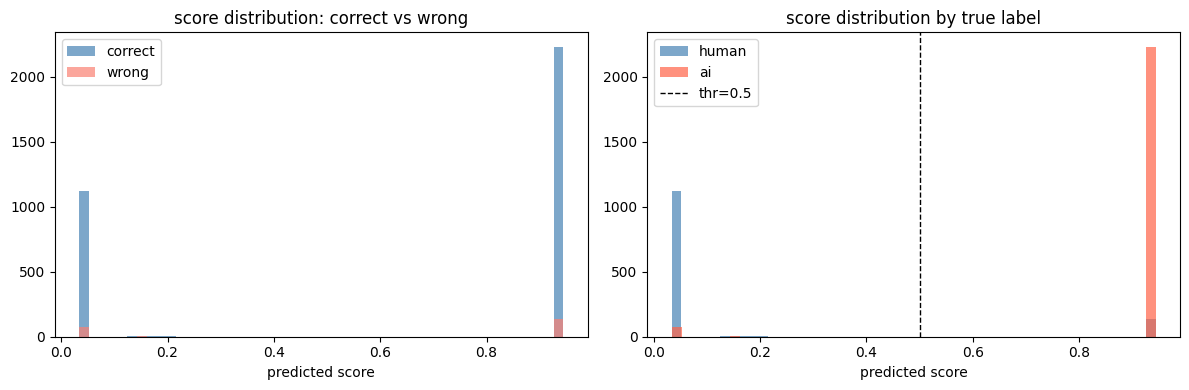

correct: 3367  wrong: 222  acc=0.9381


In [14]:
import matplotlib.pyplot as plt

probas_val = np.array([pred_map[r["id"]] for r in val_recs])
true_val = np.array([r["label"] for r in val_recs])
thr = 0.5

# score distributions correct vs wrong
correct = probas_val[(probas_val >= thr) == true_val.astype(bool)]
wrong = probas_val[(probas_val >= thr) != true_val.astype(bool)]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(correct, bins=50, alpha=0.7, label="correct", color="steelblue")
axes[0].hist(wrong, bins=50, alpha=0.7, label="wrong", color="salmon")
axes[0].set_title("score distribution: correct vs wrong")
axes[0].set_xlabel("predicted score")
axes[0].legend()

# score distribution by true label
axes[1].hist(probas_val[true_val == 0], bins=50, alpha=0.7, label="human", color="steelblue")
axes[1].hist(probas_val[true_val == 1], bins=50, alpha=0.7, label="ai", color="tomato")
axes[1].axvline(thr, color="black", linestyle="--", linewidth=1, label=f"thr={thr}")
axes[1].set_title("score distribution by true label")
axes[1].set_xlabel("predicted score")
axes[1].legend()

fig.tight_layout()
fig.savefig(str(CKPT_DIR / "score_dist.png"), dpi=100)
plt.show()
print(f"correct: {len(correct)}  wrong: {len(wrong)}  acc={len(correct)/(len(correct)+len(wrong)):.4f}")

In [15]:
import collections

completed_trials = [t for t in study.trials if t.value is not None]
pruned_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
print(f"completed: {len(completed_trials)}  pruned: {len(pruned_trials)}")

for param in ("loss_fn",):
    vals = [t.params[param] for t in completed_trials if param in t.params]
    cnt = collections.Counter(vals)
    mean_by_val = {v: float(np.mean([t.value for t in completed_trials
                                     if t.params.get(param) == v and t.value is not None]))
                   for v in cnt}
    print(f"\n{param} breakdown:")
    for v in sorted(mean_by_val, key=lambda x: -mean_by_val[x]):
        print(f"  {v:<16} trials={cnt[v]:3d}  mean_val_mean={mean_by_val[v]:.4f}")

completed: 15  pruned: 5

loss_fn breakdown:
  focal_rank       trials=  2  mean_val_mean=0.8142
  focal_only       trials=  5  mean_val_mean=0.7882
  bce_rank         trials=  6  mean_val_mean=0.6954
  bce_only         trials=  2  mean_val_mean=0.3225
